# Task 5: Personal Loan Acceptance Prediction

## Objective
Predict which customers are likely to accept a personal loan offer using classification techniques.

## Dataset
Bank Marketing Dataset (UCI Machine Learning Repository)

## Problem Statement
Banks spend significant resources on marketing campaigns. By predicting which customers are more likely to subscribe to a personal loan or term deposit offer, banks can improve targeting, reduce marketing costs, and increase conversion rates.

## Deliverables
- Data Exploration and Visualization
- Data Preprocessing
- Classification Modeling
- Logistic Regression
- Business Insight Extraction
- Model Evaluation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


## 1. Load Dataset

In [5]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Internship DA\bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Target Variable

- y = Customer accepted offer
    - yes = accepted
    - no = not accepted


## 2. Dataset Exploration

In [6]:
print('Dataset Shape:', df.shape)

display(df.head())

print('\nMissing Values:')
print(df.isnull().sum())

print('\nDuplicate Rows:', df.duplicated().sum())

df.describe(include='all')


Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Duplicate Rows: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


### Initial Observations

The dataset contains customer demographic information, financial indicators, and previous campaign outcomes that may influence offer acceptance.


## 3. Data Exploration and Visualization

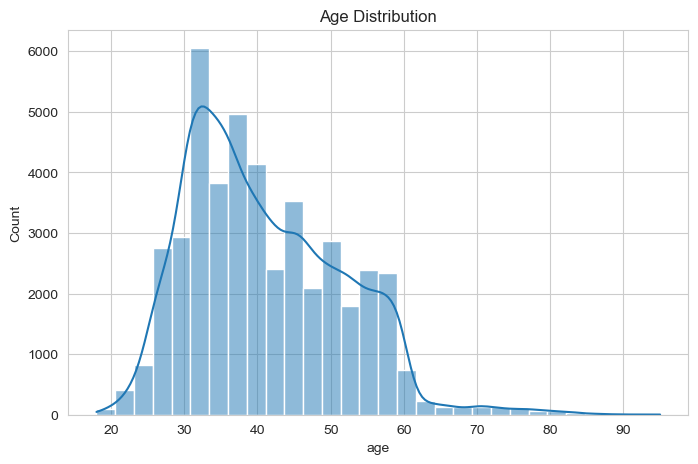

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

### Interpretation

Most customers fall within the working-age population. Understanding age distribution helps identify target customer segments.


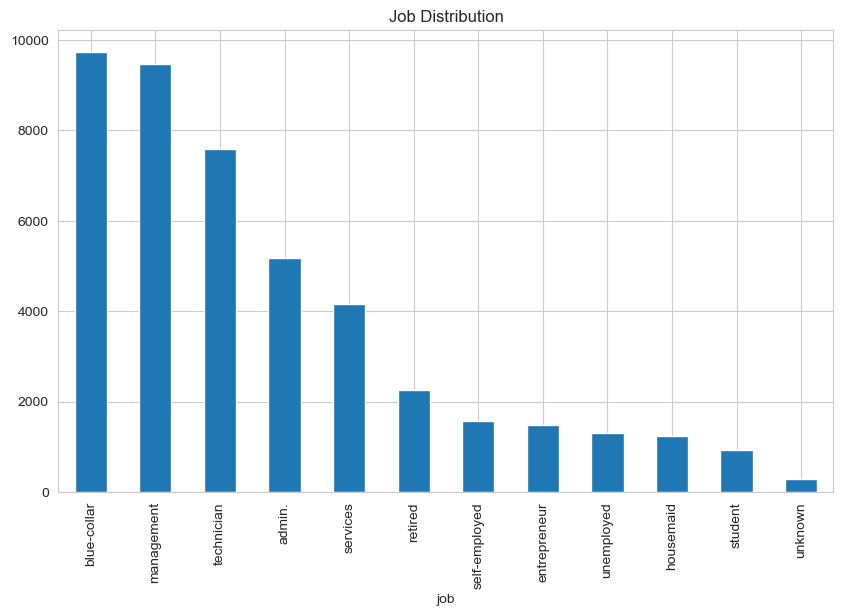

In [8]:
plt.figure(figsize=(10,6))
df['job'].value_counts().plot(kind='bar')
plt.title('Job Distribution')
plt.show()

### Interpretation

Certain occupations dominate the customer base. These groups may respond differently to loan offers.


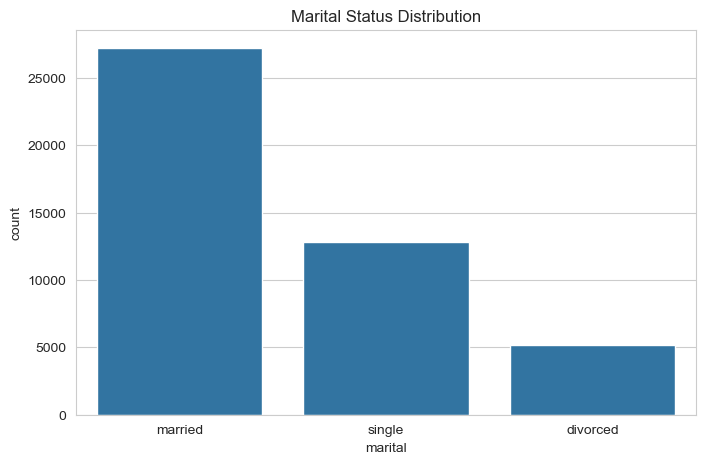

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='marital')
plt.title('Marital Status Distribution')
plt.show()

### Interpretation

Marital status may influence financial decision-making and borrowing behavior.


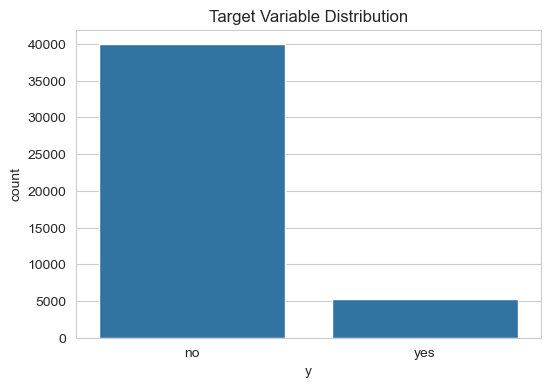

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y')
plt.title('Target Variable Distribution')
plt.show()

### Interpretation

The target distribution reveals whether class imbalance exists and whether additional techniques may be required.


## 4. Acceptance Analysis by Customer Groups

In [11]:
age_acceptance = pd.crosstab(df['age']//10*10, df['y'], normalize='index')*100
age_acceptance

y,no,yes
age,,
10,61.702128,38.297872
20,82.587065,17.412935
30,89.424512,10.575488
40,90.879451,9.120549
50,90.665874,9.334126
60,70.325203,29.674797
70,57.547170,42.452830
80,60.330579,39.669421
90,22.222222,77.777778


In [12]:
job_acceptance = pd.crosstab(df['job'], df['y'], normalize='index')*100
job_acceptance.sort_values('yes', ascending=False).head(10)


y,no,yes
job,,
student,71.321962,28.678038
retired,77.208481,22.791519
unemployed,84.497314,15.502686
management,86.244449,13.755551
admin.,87.797331,12.202669
self-employed,88.157061,11.842939
unknown,88.194444,11.805556
technician,88.943004,11.056996
services,91.116996,8.883004


In [13]:
marital_acceptance = pd.crosstab(df['marital'], df['y'], normalize='index')*100
marital_acceptance


y,no,yes
marital,,
divorced,88.054542,11.945458
married,89.876534,10.123466
single,85.050821,14.949179


### Interpretation

These analyses help identify which customer segments are most likely to accept marketing offers.


## 5. Data Preprocessing

In [14]:
df['y'] = df['y'].map({'yes':1,'no':0})

X = df.drop('y', axis=1)
y = df['y']

categorical_cols = X.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


### Why Encoding?

Machine learning models require numerical input. One-Hot Encoding converts categorical variables into numerical features.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 6. Logistic Regression Model

In [16]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=5000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 7. Model Evaluation

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', round(accuracy,4))
print('\nClassification Report')
print(classification_report(y_test, y_pred))


Accuracy: 0.9012

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



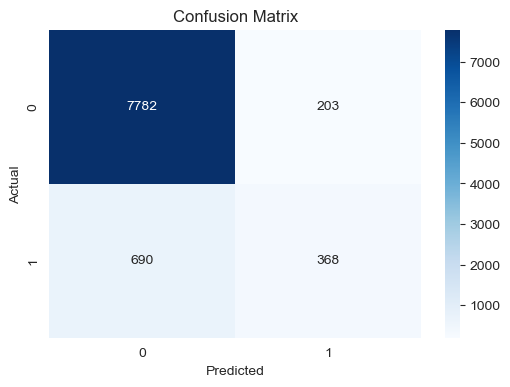

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### Evaluation Interpretation

- Accuracy measures overall prediction correctness.
- Precision measures how many predicted acceptances were correct.
- Recall measures how many actual acceptances were identified.
- F1-Score balances Precision and Recall.


## 8. Feature Importance Analysis

In [19]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coefficients = model.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

coef_df.head(15)


,Feature,Coefficient
42,cat__poutcome_success,1.500146
35,cat__month_mar,1.367953
38,cat__month_oct,0.834106
39,cat__month_sep,0.766486
5,cat__job_retired,0.451667
30,cat__month_dec,0.436387
8,cat__job_student,0.415723
34,cat__month_jun,0.401729
25,cat__contact_cellular,0.323675
26,cat__contact_telephone,0.214684


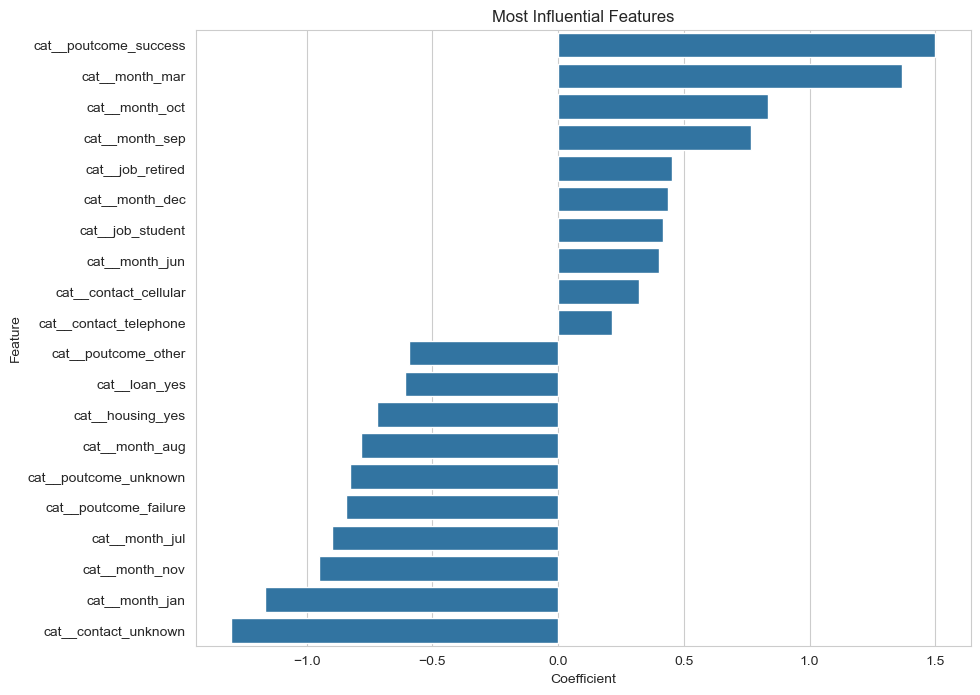

In [20]:
top_features = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
])

plt.figure(figsize=(10,8))
sns.barplot(data=top_features, x='Coefficient', y='Feature')
plt.title('Most Influential Features')
plt.show()


### Interpretation

Positive coefficients increase the likelihood of acceptance, while negative coefficients reduce it.


## 9. Business Insights

### Customer Groups More Likely to Accept

Based on exploratory analysis and model results:

1. Certain age groups demonstrate higher acceptance rates.
2. Some occupations respond more positively to marketing campaigns.
3. Marital status influences customer response behavior.
4. Previous campaign interactions strongly affect future acceptance.

### Marketing Recommendations

- Prioritize high-conversion customer segments.
- Focus campaigns on customer groups with historically high acceptance rates.
- Use predictive models before launching campaigns to reduce costs.
- Personalize offers based on demographic and financial profiles.


# Conclusion

A Logistic Regression model was developed to predict personal loan acceptance.

### Project Achievements

✔ Data exploration completed

✔ Age, job, and marital status analyzed

✔ Logistic Regression model trained

✔ Classification metrics evaluated

✔ Customer segments identified

✔ Business recommendations generated

### Final Summary

The model helps banks identify customers most likely to accept a loan offer, enabling more efficient marketing strategies and better resource allocation.
